# Academic Summary: GFlowNet Foundations

# https://arxiv.org/pdf/2111.09266

## Abstract
This paper by Bengio, Lahlou, Deleu, Hu, Tiwari, and Bengio (JMLR, 2023) provides an in-depth theoretical foundation for Generative Flow Networks (GFlowNets), extending the original formulation introduced by Bengio et al. (2021). GFlowNets are trained to sample compositional objects $$s$$ through a sequence of stochastic constructive steps such that the probability of sampling a terminating state is approximately proportional to a given reward function $$R(s)$$. The paper formalizes the mathematical theory of flow networks, introduces a new local training objective called detailed balance, and extends GFlowNets to estimate free energies, entropies, mutual information, and marginal/conditional distributions over sets, graphs, and supergraphs, with further extensions to stochastic environments and continuous action spaces.

## Problems
- **Intractable sampling from unnormalized densities**: Standard approaches such as Markov Chain Monte Carlo (MCMC) suffer from mode-mixing intractability, requiring exponentially long chains to transition between separated modes of a target distribution.
- **Lack of formal theoretical grounding**: The original GFlowNet paper (Bengio et al., 2021) proposed the flow-matching objective but lacked a rigorous mathematical framework connecting flows, trajectories, and probability measures.
- **Marginalization over composite/structured objects**: Computing free energies, entropies, and marginal probabilities over sets and graphs (e.g., given a subset of variables) is generally intractable via standard methods.
- **Training instability and inefficiency**: The original flow-matching loss requires forming explicit sums over neighboring states, which is expensive and does not generalize easily to continuous or high-dimensional discrete spaces.

## Proposed Solutions
1. **Formal theory of flow networks**: A rigorous graph-theoretic definition of pointed DAGs, trajectory flows, Markovian flows, and their equivalence classes.
2. **Detailed balance training objective**: A new local objective analogous to the detailed balance condition in MCMC theory, avoiding explicit summation over children/parents required by the flow-matching loss:
$$
\hat{F}(s)\hat{P}_F(s'\mid s) = \hat{F}(s')\hat{P}_B(s\mid s').
$$
3. **Conditional and state-conditional GFlowNets**: A mechanism for marginalizing over downstream terminating states from any internal state $$s$$, enabling estimation of free energies:
$$
e^{-\mathcal{F}(s)} := \sum_{s' \geq s} e^{-E(s')}.
$$
4. **Entropy and mutual information estimators**: Training two GFlowNets (one on the reward $$R$$, one on the entropic reward $$R'(s) = -R(s)\log R(s)$$) to recover Shannon entropy and mutual information via initial-state flows.
5. **Set/graph GFlowNet formalization**: Generalizing GFlowNets to construct sets and graphs incrementally, enabling estimation of subset marginal probabilities and superset conditional probabilities.
6. **Extensions**: Trajectory-balance loss (Malkin et al., 2022) recap, stochastic reward/environment handling, continuous and hybrid action spaces, modular energy-function decomposition (factor graphs), and Pareto-front sampling via outcome-conditioned GFlowNets.

## Purpose
The paper aims to establish a comprehensive theoretical foundation for GFlowNets as amortized probabilistic inference machines — an alternative to MCMC that trades expensive per-sample iterative computation for a one-time training cost, while preserving the ability to represent and sample from rich, multimodal distributions over compositional/discrete objects such as molecules, graphs, and structured data.

## Methodology
- **Graph-theoretic construction**: A pointed DAG $$G = (S, A)$$ with initial state $$s_0$$ and sink state $$s_f$$; trajectories $$\tau$$ define a measure space, and flows $$F(\tau)$$ induce probability measures $$P(\tau) = F(\tau)/Z$$, with total flow $$Z$$ serving as the partition function.
- **Markovian flow characterization**: Proof (Propositions 16–23) that trajectory probabilities factorize according to forward/backward transition probabilities $$P_F, P_B$$, and that each equivalence class of flows contains a unique Markovian representative — justifying the restriction to Markovian flows for tractable learning.
- **Flow parametrizations and losses**: Formal definitions of flow parametrizations $$(O, \Pi, H)$$ and flow-matching losses (edge-, state-, and trajectory-decomposable), with worked examples: edge-flow parametrization (original GFlowNet loss), forward/backward transition parametrization (detailed balance loss), and trajectory balance loss.
- **Conditional flow networks**: Formal treatment of reward-conditional and state-conditional flow networks, with proofs establishing marginalization properties (Propositions 31–33).
- **Theoretical proofs**: Extensive use of measure-theoretic and probabilistic arguments (strong induction, conditional probability decomposition) to establish correctness of all proposed objectives.
- **No empirical experiments**: The paper is purely theoretical; it references prior/contemporary empirical studies (e.g., Bengio et al. 2021 on molecule generation, Deleu et al. 2022 on Bayesian structure learning, Jain et al. 2022/2023 on biological sequence design) for validation rather than presenting new experiments.

## Results
As a theoretical contribution, "results" consist of formally proven propositions and theorems rather than empirical benchmarks:
- **Proposition 21 (Detailed balance)**: Establishes that detailed balance conditions uniquely define a Markovian flow, avoiding explicit sums over successor/predecessor sets required by flow matching.
- **Proposition 23**: Every equivalence class of flows contains a unique Markovian flow, justifying restriction of GFlowNet learning to Markovian flows without loss of generality.
- **Proposition 32**: The initial state-conditional flow equals the exponential negative free energy, i.e., $$F_s(s_0\mid s) = e^{-\mathcal{F}(s)}$$, enabling tractable free-energy estimation.
- **Propositions 35–36**: Closed-form estimators for entropy $$H[S]$$, conditional entropy $$H[S\mid x]$$, and mutual information $$MI(S;X)$$ using paired GFlowNets trained on $$R$$ and its entropic transform $$R'$$.
- **Proposition 38**: Marginal probability over all supersets of a given set $$s$$ can be computed from the state-conditional flow: $$P_T(\mathcal{S}(s)) = F(s\mid s)/F(s_0)$$.
- **Contrast with MaxEnt RL (Section 7.2)**: Formally distinguishes GFlowNets from entropy-regularized RL, showing MaxEnt RL policies induce $$P_T(s) \propto n(s)R(s)$$ (biased by the number of paths $$n(s)$$ to $$s$$), whereas GFlowNets achieve unbiased $$P_T(s)\propto R(s)$$.
- **Appendix results**: Direct credit-assignment gradient estimators (Propositions 39–41) shown to be asymptotically unbiased at the flow-matching fixed point; counterexamples (Fig. 6) demonstrating that backward transition probabilities cannot always be freely chosen in stochastic environments.

## Conclusions
- The paper deepens the mathematical foundation of GFlowNets by formally connecting flow networks to measure theory and probability over trajectories, establishing the detailed balance loss as a principled, locally computable alternative to flow matching.
- Conditional GFlowNets enable a general-purpose mechanism for marginalization, allowing estimation of free energies, entropies, and mutual information — previously intractable quantities in high-dimensional discrete spaces.
- GFlowNets are theoretically positioned as amortized inference machines distinct from both MCMC (avoiding mode-mixing at sampling time, at the cost of upfront training) and entropy-regularized RL (avoiding path-count bias).
- The framework extends naturally to sets, graphs, factor-graph energy decompositions, stochastic environments, and continuous/hybrid state-action spaces, though several extensions (e.g., stochastic environments, continuous GFlowNets) are noted as open problems requiring further theoretical and empirical validation.
- The work lays groundwork for downstream applications in active learning, Bayesian structure learning, molecular design, and energy-based modeling, several of which had already demonstrated empirical success using the theoretical tools formalized in this paper.

# Mathematical and Statistical Content of "GFlowNet Foundations"

## 1. Graph-Theoretic Foundations

**Pointed DAG**: A directed acyclic graph $$G=(S,A)$$ with a unique source state $$s_0$$ and sink state $$s_f$$, such that every other state lies on some path from $$s_0$$ to $$s_f$$. This models the "construction process" of an object as a path through states.

**Partial order**: $$s < s'$$ means there is a path from $$s$$ to $$s'$$. Used to define ancestors/descendants of a state.

**Trajectory**: A path $$\tau = (s_0, s_1, \dots, s_n, s_f)$$ from source to sink. $$\mathcal{T}$$ denotes the set of all complete trajectories.

## 2. Forward and Backward Probability Functions

$$
\hat{P}_F(s'\mid s):\ \sum_{s'\in \text{Child}(s)} \hat{P}_F(s'\mid s) = 1,\qquad
\hat{P}_B(s\mid s'):\ \sum_{s\in \text{Par}(s')} \hat{P}_B(s\mid s') = 1
$$

These are simply normalized "next-step" (forward) and "previous-step" (backward) probabilities at each state, analogous to transition probabilities in a Markov chain, but defined over a DAG instead of a general graph.

## 3. Flow and Flow Network

**Trajectory flow**: A non-negative function $$F:\mathcal{T}\to \mathbb{R}^+$$, interpreted as "how many particles" travel along each path — analogous to an unnormalized measure over trajectories.

**State flow / Edge flow**:
$$
F(s) := \sum_{\tau: s\in\tau} F(\tau), \qquad F(s\to s') := \sum_{\tau: s\to s'\in \tau} F(\tau)
$$
These sum the flow of all trajectories passing through a given state or edge — like marginalizing a joint distribution over trajectories down to a single state/edge.

**Flow conservation (Proposition 8)**:
$$
F(s) = \sum_{s'\in \text{Child}(s)} F(s\to s') = \sum_{s\in \text{Par}(s')} F(s\to s')
$$
This is a Kirchhoff-style conservation law: total flow into a state equals flow out, just like current in an electrical circuit.

## 4. Total Flow and Probability Measure

$$
Z := F(\mathcal{T}) = \sum_{\tau} F(\tau)
$$

$$Z$$ is the **normalizing constant** (analogous to a partition function in statistical mechanics). Dividing by $$Z$$ turns the flow into a proper probability:
$$
P(A) := \frac{F(A)}{Z}
$$

**Forward/backward transition probabilities**:
$$
P_F(s'\mid s) = \frac{F(s\to s')}{F(s)}, \qquad P_B(s\mid s') = \frac{F(s\to s')}{F(s')}
$$
These are simply conditional probabilities derived from the flow — the probability of taking a specific step given you're at a state.

**Terminating state probability**:
$$
P_T(s) := P(s\to s_f) = \frac{F(s\to s_f)}{Z}
$$
This is the key quantity: the probability that the GFlowNet's construction process ends at a particular object $$s$$, shown to be a valid distribution (sums to 1) over terminating states.

## 5. Markovian Flows

A flow is **Markovian** if the next step depends only on the current state, not the full history — the DAG analogue of the Markov property:
$$
P(s\to s'\mid \tau) = P_F(s'\mid s)
$$

**Key theorem (Proposition 16)**: A flow is Markovian if and only if trajectory probabilities factorize as a product of forward transitions:
$$
P(\tau) = \prod_{t=1}^{n+1} P_F(s_t\mid s_{t-1})
$$
This is analogous to the Markov chain rule $$P(x_1,\dots,x_n)=\prod_t P(x_t\mid x_{t-1})$$, and it justifies representing an exponentially large object (a flow over all trajectories) using only local, per-edge quantities.

## 6. Flow Matching Conditions

$$
\hat{F}(s') = \sum_{s\in \text{Par}(s')} \hat{F}(s\to s') = \sum_{s''\in \text{Child}(s')} \hat{F}(s'\to s'')
$$
This is a **conservation constraint** that any valid flow estimate must satisfy at every internal state — the sum of incoming "probability mass" equals outgoing mass, similar to steady-state balance equations in queueing theory.

## 7. Detailed Balance Condition

$$
\hat{F}(s)\,\hat{P}_F(s'\mid s) = \hat{F}(s')\,\hat{P}_B(s\mid s')
$$
Analogous to the **detailed balance condition in MCMC** (used to guarantee a Markov chain's stationary distribution matches a target), this is a *local, pairwise* constraint (only involves two adjacent states), avoiding the need to sum over all children/parents as in flow matching. It is the basis of the "detailed balance loss," which is computationally cheaper.

## 8. Loss Functions (Training Objectives)

**Flow-matching loss** (Example 4), a squared log-ratio penalizing mismatch between incoming and outgoing flow at each state:
$$
L_{FM}(\hat{F},s') = \left(\log\frac{\delta+\sum_{s} \hat{F}(s\to s')}{\delta+R(s')+\sum_{s''}\hat{F}(s'\to s'')}\right)^2
$$

**Detailed-balance loss** (Example 5):
$$
L_{DB} = \left(\log\frac{\delta+\hat{F}(s)\hat{P}_F(s'\mid s)}{\delta+\hat{F}(s')\hat{P}_B(s\mid s')}\right)^2
$$

**Trajectory-balance loss** (Example 6):
$$
L_{TB}(\hat{Z},\hat{P}_F,\hat{P}_B,\tau) = \left(\log \frac{\hat{Z}\prod_{t=1}^{n+1}\hat{P}_F(s_t\mid s_{t-1})}{R(s_n)\prod_{t=1}^n \hat{P}_B(s_{t-1}\mid s_t)}\right)^2
$$

All three are variants of a squared-log-ratio loss (like a log-space mean-squared error), each using a different parametrization of the flow. The constant $$\delta \geq 0$$ is a small regularizer preventing instability when flows are near zero, similar to Laplace smoothing.

Minimization is framed as a stochastic optimization problem:
$$
\min_{o\in O} \mathbb{E}_{(s\to s')\sim \pi_T}[L(o, s\to s')]
$$
which is solved via stochastic gradient descent, exactly as in standard deep learning.

## 9. Free Energy and Marginalization

**Free energy** of a state $$s$$, given an energy function $$E$$:
$$
e^{-\mathcal{F}(s)} := \sum_{s'\geq s} e^{-E(s')}
$$
This generalizes the statistical-mechanics free energy: it is the log of a sum of exponentiated negative energies over all "descendants" of $$s$$ — i.e., a partial partition function. It formalizes the intractable marginalization sum that GFlowNets are designed to approximate.

**State-conditional flow networks**: A construction where, for each state $$s$$, a sub-flow network is defined over only its descendants, satisfying
$$
F_s(s_0\mid s) = \sum_{s'\geq s} F(s'\to s_f) = e^{-\mathcal{F}(s)}
$$
This shows that the free energy at $$s$$ can be recovered as an initial flow of a re-anchored sub-network — the mathematical trick enabling tractable marginal computation.

## 10. Entropy and Mutual Information Estimation

**Entropic reward transformation**:
$$
R'(s) = -R(s)\log R(s)
$$

**Entropy formula** (Proposition 35), derived by training a second GFlowNet on $$R'$$:
$$
H[S] = -\sum_s P_T(s)\log P_T(s) = \frac{F'(s_0)}{F(s_0)} + \log F(s_0)
$$
This is the standard Shannon entropy formula, re-expressed in terms of flows so it can be estimated by reading off two initial-state flow values rather than computing an intractable sum directly.

**Conditional entropy and mutual information** (Proposition 36):
$$
H[S\mid x] = \frac{F'(s_0\mid x)}{F(s_0\mid x)} + \log F(s_0\mid x)
$$
$$
MI(S;X) = H[S] - \mathbb{E}_X[H[S\mid X]]
$$
Standard information-theoretic identities, computed via the same flow-based trick applied to conditional GFlowNets.

## 11. Set and Superset Probabilities

For GFlowNets that build sets element by element, the probability of landing in *any* superset of a given set $$s$$:
$$
P_T(\mathcal{S}(s)) = \sum_{s'\supseteq s} P_T(s') = \frac{F(s\mid s)}{F(s_0)} = \frac{e^{-\mathcal{F}(s)}}{Z}
$$
This is a marginal probability computation (summing over all completions of a partial set) — analogous to computing $$P(X_1 = x_1) = \sum_{x_2} P(X_1=x_1, X_2=x_2)$$ in a joint distribution, made tractable via the free-energy/flow identity above.

## 12. Comparison with Maximum-Entropy Reinforcement Learning

MaxEnt RL trajectory distribution:
$$
p(\tau) \propto \left[p(s_0)\prod_{t} P(s_{t+1}\mid s_t,a_t)\right]\exp\left(\eta\sum_t R(s_t,a_t)\right)
$$
The paper shows GFlowNets differ fundamentally: MaxEnt RL yields $$P_T(s)\propto n(s)R(s)$$, where $$n(s)$$ is the number of distinct paths to $$s$$ (a combinatorial multiplicity factor), whereas GFlowNets achieve the unbiased $$P_T(s)\propto R(s)$$. This is a key statistical distinction: GFlowNets correct for "path-counting bias" that standard entropy-regularized policies do not.

## 13. Direct Credit Assignment (Gradient Estimators)

Using implicit differentiation through the flow-matching constraint:
$$
\frac{d\log F(s')}{d\log F(s)} = P(s\mid s'), \qquad \frac{d\log F(s')}{d\log F(s\to s')} = P_B(s\mid s')
$$
These are sensitivity analyses — showing how a small perturbation in flow at one state propagates to another, analogous to computing partial derivatives via the chain rule in a computational graph (backpropagation-like reasoning applied to the flow-matching constraint).

**Unbiased gradient estimators** (Proposition 41): Two Monte Carlo estimators $$G_1, G_2$$, and any convex combination $$G=\lambda G_1+(1-\lambda)G_2$$, are shown to be asymptotically unbiased estimates of the true loss gradient $$\frac{dL}{d\theta}$$ — a standard stochastic-gradient-estimation argument (like REINFORCE/policy-gradient estimators in RL), proven via nested expectation and the chain rule.

## 14. Value Functions and Policy Improvement

**Expected downstream reward**:
$$
V_{P_\pi}(s) := \mathbb{E}_{P_\pi(S)}[R(S)\mid S\geq s] = \sum_{s'\geq s} R(s')P_\pi(s'\mid s\leq s')
$$
This is directly analogous to the **value function** $$V(s)$$ in reinforcement learning — expected future reward from state $$s$$ onward.

**Policy improvement theorem (Proposition 53)**: A greedy policy with respect to $$V_{P_\pi}$$ never performs worse:
$$
V_{P_{\bar\pi}}(s) \geq V_{P_\pi}(s)
$$
This mirrors the classical RL policy-improvement theorem, proven here via a telescoping inequality argument.

## 15. Trajectory Return (Non-Terminal Rewards)

$$
\rho(\tau) = \sum_{t=i}^{n} R(s_t), \qquad \bar\rho(s_t) = R(s_t) + \sum_{s_{t+1}} P_F(s_{t+1}\mid s_t)\bar\rho(s_{t+1})
$$
This recursive formula is exactly the **Bellman equation** without discounting — used to extend GFlowNets from single terminal rewards to cumulative (per-step) rewards.

## 16. Statistical Distribution Design (Pareto/Multi-objective)

$$
R_\omega(s) = \sum_i \omega_i f_i(s) \quad \text{(additive)}, \qquad R_\omega(s) = e^{-\sum_i \omega_i e_i(s)} \quad \text{(multiplicative)}
$$
These define families of reward functions parametrized by convex weights $$\omega$$ (with $$\omega_i\geq 0,\ \sum_i \omega_i = 1$$), used to sample from the Pareto frontier of multiple objectives — a scalarization technique common in multi-objective optimization.

## Summary of Role in the Paper

| Concept | Statistical Role |
|---|---|
| Flow / trajectory measure | Defines an unnormalized probability model over generative paths |
| Markovian flow factorization | Enables tractable, local parametrization (like Markov chains) |
| Flow matching / detailed balance / trajectory balance losses | Alternative loss functions (squared log-ratio) for training via SGD |
| Free energy | Generalized partition function for marginal probability computation |
| Entropy/mutual information formulas | Information-theoretic quantities computed via auxiliary flow networks |
| Value function and Bellman recursion | Connects GFlowNet theory to reinforcement learning |
| Gradient estimators | Justify unbiased stochastic optimization of the flow objectives |

All mathematical machinery serves one unifying statistical goal: to train a generative sampler whose terminal-state distribution is provably proportional to a given (possibly unnormalized) reward/energy function, while enabling tractable estimation of downstream quantities (partition function, marginals, entropy, mutual information) that are otherwise computationally intractable.

# Key Problems, Limitations, and Proposed Solutions in "GFlowNet Foundations"

| # | Key Problem / Research Gap | Limitation of Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | Sampling from unnormalized target distributions (reward/energy functions) over compositional discrete objects (e.g., graphs, sets) is computationally intractable. | MCMC methods require long stochastic chains and suffer from the **mode-mixing problem**: transitioning between distant, separated modes can take exponentially long, especially in high dimensions. | GFlowNets amortize the sampling cost into a one-time training phase, converting the energy/reward function into a generative policy that produces i.i.d. samples in a single forward pass, avoiding iterative chain-based mixing. |
| 2 | The original GFlowNet formulation (Bengio et al., 2021) lacked a rigorous mathematical foundation connecting flows, trajectories, and probability theory. | Flow matching was proposed heuristically without a formal proof of equivalence between trajectory flows, Markovian flows, and induced probability measures, limiting theoretical understanding and extensibility. | The paper formalizes flow networks using measure theory (pointed DAGs, trajectory flow functions, flow-induced probability measures) and proves that every flow equivalence class contains a unique **Markovian flow**, justifying restriction to Markovian parametrizations for tractable learning. |
| 3 | The original flow-matching loss requires explicit summation over all children/parents of a state at each training step. | This summation is expensive or intractable when states have large or unbounded numbers of successors, and is not well-suited to continuous or high-dimensional discrete action spaces. | A new **detailed balance** loss is introduced, analogous to the detailed balance condition in MCMC, which is a local, pairwise constraint between adjacent states requiring no explicit summation, improving computational efficiency and scalability. |
| 4 | Estimating marginal probabilities, free energies, entropy, and mutual information over composite objects (e.g., given a subset of variables/graph) is generally intractable. | Prior GFlowNet work only supported estimating the terminal-state distribution and the global partition function (via the initial-state flow); it provided no mechanism for marginalizing over descendants of an arbitrary internal state, since state flow $$F(s)$$ does not equal the sum of downstream terminating flows (illustrated via counterexample in Fig. 5). | The paper introduces **conditional GFlowNets** and **state-conditional flow networks**, proving that a re-anchored sub-network's initial flow correctly recovers the free energy $$e^{-\mathcal{F}(s)} = \sum_{s'\geq s} F(s'\to s_f)$$, enabling tractable marginalization, free-energy estimation, and computation of entropy/conditional entropy/mutual information. |
| 5 | No established mechanism existed to sample from and estimate probabilities over structured, variable-size composite objects (sets, graphs, joint variable assignments) with support for conditional and marginal queries. | Standard generative models (VAEs, GANs, normalizing flows) are designed for fixed-size, typically continuous latent representations and require a fixed dataset of positive examples rather than an energy/reward function; they do not naturally support subset/superset conditional queries. | The paper formalizes **set GFlowNets** and **graph GFlowNets**, defining actions as incremental element/edge insertion, and derives formulas for conditional superset probabilities and marginal probabilities over subsets of variables. |
| 6 | The relationship between GFlowNets and other RL/inference paradigms (MaxEnt RL, MCMC, SMC, evolutionary methods) was not clearly delineated, risking conflation of GFlowNets with reward-maximizing or entropy-regularized policies. | Entropy-regularized (MaxEnt) RL policies are commonly assumed to sample proportionally to reward, but this is not generally true: MaxEnt RL policies sample states with probability biased by the number of paths $$n(s)$$ leading to them ($$P_T(s)\propto n(s)R(s)$$), unlike GFlowNets. | The paper provides a formal theoretical comparison (Section 7), proving that GFlowNets achieve unbiased $$P_T(s)\propto R(s)$$ regardless of path multiplicity, distinguishing them from MaxEnt RL, and clarifying differences from MCMC (single-pass vs. iterative sampling) and SMC (terminal-only vs. per-step reweighting). |
| 7 | The framework was originally restricted to deterministic, discrete-action environments, limiting applicability to real-world or continuous-valued domains. | Real-world tasks may involve continuous states/actions or stochastic environment transitions, which the original discrete, deterministic GFlowNet formulation could not accommodate. | The paper proposes extensions for **continuous/hybrid states and actions** (via integrable normalization constants or nested GFlowNet-in-GFlowNet modules) and for **stochastic environments** (via even/odd state decomposition separating agent policy from environment transition), while proving via counterexample (Fig. 6) that backward transition probabilities cannot always be chosen freely under stochastic dynamics. |
| 8 | Training a GFlowNet purely from a static reward function does not account for scenarios involving intermediate rewards, non-stationary objectives, or multiple competing objectives. | Existing GFlowNet formulations assumed a single terminal reward function known a priori, without support for cumulative per-step rewards, distributional generalization, or multi-objective/Pareto-optimal sampling. | The paper introduces **return-augmented GFlowNets** (via a Bellman-style recursion for cumulative reward), **outcome-conditioned/distributional GFlowNets**, and **Pareto GFlowNets** (conditioned on convex objective weights $$\omega$$) to support intermediate rewards, distributional statistics, and multi-objective sampling without retraining. |
| 9 | Credit assignment in flow-matching/detailed-balance training propagates slowly (via bootstrapping) across long trajectories, similar to temporal-difference learning inefficiencies. | Slow bootstrapped credit propagation can require many training updates before reward information at terminal states influences early transition probabilities, particularly problematic for long trajectories. | The paper derives (Appendix A) **direct credit assignment** gradient estimators using implicit differentiation through the flow-matching constraint, proving these estimators are asymptotically unbiased and provide policy-gradient-like updates to early transitions without waiting for full bootstrapped propagation. |

In [1]:
# ==============================================================================
# EDUCATIONAL REPLICATION: GFlowNet-Inspired CNN Classifier on CIFAR-10
# ------------------------------------------------------------------------------
# NOTE: GFlowNets (Bengio et al., "GFlowNet Foundations") are generative
# samplers designed to sample compositional objects proportionally to a reward
# function -- they are NOT classifiers. This script is a SIMPLIFIED,
# EDUCATIONAL adaptation that borrows the paper's core mathematical idea
# (a "flow" quantity that must stay internally consistent, trained with a
# detailed-balance-style auxiliary loss) and attaches it to a standard image
# classification pipeline so we can visualize training dynamics on CIFAR-10.
#
# Two loss components are trained jointly (mirroring the paper's idea that a
# GFlowNet has: (1) a policy/reward-matching objective, and (2) a flow
# consistency objective):
#   1) Classification loss (Cross-Entropy)      -> the "reward-matching" task
#   2) Flow-consistency loss (Detailed-Balance-inspired MSE) -> auxiliary task
#
# This code is written for beginners: every major section is commented.
# ==============================================================================

# ------------------------------------------------------------------------------
# SECTION 0: IMPORTS
# ------------------------------------------------------------------------------
import io
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as T

from datasets import load_dataset

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn.metrics import confusion_matrix

from IPython.display import display, Image as IPImage

In [2]:
# ------------------------------------------------------------------------------
# SECTION 1: GLOBAL CONFIG
# ------------------------------------------------------------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS = 5          # Train for 5 epochs only, as required
BATCH_SIZE = 64
NUM_CLASSES = 10
IMG_SIZE = 64
LAMBDA_FLOW = 0.1        # Weight of the auxiliary flow-consistency loss

# CIFAR-10 class names, in the exact order required (labels 0-9)
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

In [ ]:
# ------------------------------------------------------------------------------
# SECTION 2: DATASET LOADING (HuggingFace CIFAR-10 ONLY)
# ------------------------------------------------------------------------------
# Load CIFAR-10 exclusively from HuggingFace (never torchvision.datasets.CIFAR10)
ds = load_dataset("uoft-cs/cifar10")

# --- Transform pipelines -----------------------------------------------------
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# --- Custom PyTorch Dataset wrapper around a HuggingFace split ---------------
class HFCifar10Dataset(Dataset):
    """
    Wraps a HuggingFace CIFAR-10 split so it behaves like a standard
    PyTorch Dataset: reading the 'img' field as a PIL image, converting
    to RGB, applying a torchvision transform pipeline, and returning
    (image_tensor, label) from the 'label' field.
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        sample = self.hf_split[idx]
        img = sample["img"]                # PIL Image
        if img.mode != "RGB":
            img = img.convert("RGB")       # ensure 3-channel RGB
        img_tensor = self.transform(img)   # apply resize/flip/tensor/normalize
        label = int(sample["label"])       # integer class label 0-9
        return img_tensor, label


# --- Wrap the HuggingFace splits ----------------------------------------------
train_dataset_full = HFCifar10Dataset(ds["train"], transform=train_transform)
test_dataset_full = HFCifar10Dataset(ds["test"], transform=test_transform)

# --- Take small subsets for a fast, educational run ---------------------------
train_dataset = Subset(train_dataset_full, list(range(2000)))
test_dataset = Subset(test_dataset_full, list(range(400)))

# --- DataLoaders ---------------------------------------------------------------
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

# --- Sanity check ---------------------------------------------------------------
sample_images, sample_labels = next(iter(train_loader))
print("=" * 60)
print("DATASET SANITY CHECK")
print("=" * 60)
print(f"Number of training samples : {len(train_dataset)}")
print(f"Number of test samples     : {len(test_dataset)}")
print(f"Shape of one image batch   : {tuple(sample_images.shape)}")
print(f"Label range                : [{sample_labels.min().item()}, {sample_labels.max().item()}]")
print(f"First 8 class names        : {[CLASS_NAMES[l] for l in sample_labels[:8].tolist()]}")
print("=" * 60)

In [4]:
# ------------------------------------------------------------------------------
# SECTION 3: MODEL DEFINITION
# ------------------------------------------------------------------------------
class GFlowNetInspiredCNN(nn.Module):
    """
    A simple CNN backbone with two output heads:

      1) Classification head -> predicts class logits (the "reward-matching"
         task, analogous to a GFlowNet's terminal reward function R(s)).

      2) Flow head -> predicts a single scalar "log flow" value per image.
         Inspired by the paper's Detailed Balance condition:
             F(s) * P_F(s'|s) = F(s') * P_B(s|s')
         Here we use a simplified, educational proxy: the flow head is
         trained to regress the log-sum-exp of the classification logits
         (a proxy for a per-sample partition function / total flow Z),
         which encourages the network to learn an internally consistent
         "flow" representation alongside the classification task -- exactly
         as a GFlowNet jointly maintains flow-consistency alongside
         reward-matching.
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        # --- Convolutional feature extractor (backbone) ---
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 64 -> 32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32 -> 16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16 -> 8

            nn.AdaptiveAvgPool2d((4, 4)),  # fixed-size feature map
        )

        self.flatten_dim = 128 * 4 * 4

        # Shared trunk (fully connected)
        self.trunk = nn.Sequential(
            nn.Linear(self.flatten_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
        )

        # Head 1: classification logits (reward-matching task)
        self.classifier_head = nn.Linear(256, num_classes)

        # Head 2: scalar log-flow estimate (detailed-balance-inspired task)
        self.flow_head = nn.Linear(256, 1)

    def forward(self, x):
        feats = self.features(x)
        feats = feats.view(feats.size(0), -1)   # flatten
        shared = self.trunk(feats)

        logits = self.classifier_head(shared)          # (B, num_classes)
        log_flow_pred = self.flow_head(shared).squeeze(-1)  # (B,)

        return logits, log_flow_pred


model = GFlowNetInspiredCNN(num_classes=NUM_CLASSES).to(DEVICE)

# Count trainable parameters (used later in the dashboard)
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_trainable_params:,}")

Total trainable parameters: 621,067


In [5]:
# ------------------------------------------------------------------------------
# SECTION 4: LOSS FUNCTIONS AND OPTIMIZER
# ------------------------------------------------------------------------------
classification_criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


def flow_consistency_loss(logits, log_flow_pred):
    """
    Educational, simplified Detailed-Balance-inspired auxiliary loss.

    In the paper, detailed balance requires:
        F(s) * P_F(s'|s) = F(s') * P_B(s|s')
    which, in log-space, becomes a squared-log-ratio consistency loss.

    Here we use a simplified proxy target: the log-sum-exp of the
    classification logits acts as a stand-in "total flow" Z for that
    sample (i.e., log Z = log sum_y exp(logit_y)). The flow head is
    trained (via MSE in log-space, just like the paper's squared-log-ratio
    losses) to match this quantity, encouraging the network to learn an
    internally consistent notion of "flow" alongside classification.
    """
    with torch.no_grad():
        log_target = torch.logsumexp(logits, dim=1)  # proxy log Z per sample
    return F.mse_loss(log_flow_pred, log_target)

In [6]:
# ------------------------------------------------------------------------------
# SECTION 5: TRAINING & VALIDATION LOOP
# ------------------------------------------------------------------------------
history = {
    "train_total_loss": [],
    "val_total_loss": [],
    "train_cls_loss": [],
    "val_cls_loss": [],
    "train_flow_loss": [],
    "val_flow_loss": [],
    "train_acc": [],
    "val_acc": [],
}

# For Panel F: epoch-wise per-class accuracy heatmap
per_class_acc_per_epoch = []  # list of arrays, shape (num_classes,)

# We keep the LAST epoch's predictions/labels/confidences for confusion
# matrix, per-class accuracy bar chart, and confidence histogram.
final_val_preds = None
final_val_labels = None
final_val_confidences = None
final_val_correct_mask = None


def run_epoch(loader, train_mode):
    """
    Runs one full pass over `loader`. If train_mode=True, performs
    backpropagation and weight updates; otherwise runs in eval mode.
    Returns average total loss, average classification loss,
    average flow loss, accuracy, and (for the last-seen epoch) full
    prediction/label/confidence arrays.
    """
    if train_mode:
        model.train()
    else:
        model.eval()

    total_loss_sum = 0.0
    cls_loss_sum = 0.0
    flow_loss_sum = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_confidences = []

    context = torch.enable_grad() if train_mode else torch.no_grad()
    with context:
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            if train_mode:
                optimizer.zero_grad()

            logits, log_flow_pred = model(images)

            cls_loss = classification_criterion(logits, labels)
            flow_loss = flow_consistency_loss(logits, log_flow_pred)
            total_loss = cls_loss + LAMBDA_FLOW * flow_loss

            if train_mode:
                total_loss.backward()
                optimizer.step()

            probs = F.softmax(logits, dim=1)
            confidences, preds = torch.max(probs, dim=1)

            total_loss_sum += total_loss.item() * images.size(0)
            cls_loss_sum += cls_loss.item() * images.size(0)
            flow_loss_sum += flow_loss.item() * images.size(0)
            correct += (preds == labels).sum().item()
            total += images.size(0)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
            all_confidences.append(confidences.detach().cpu())

    avg_total_loss = total_loss_sum / total
    avg_cls_loss = cls_loss_sum / total
    avg_flow_loss = flow_loss_sum / total
    accuracy = correct / total

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_confidences = torch.cat(all_confidences).numpy()

    return avg_total_loss, avg_cls_loss, avg_flow_loss, accuracy, all_preds, all_labels, all_confidences


print("\nStarting training...\n")
for epoch in range(1, NUM_EPOCHS + 1):
    # --- Training pass ---
    train_total, train_cls, train_flow, train_acc, _, _, _ = run_epoch(
        train_loader, train_mode=True
    )

    # --- Validation pass ---
    (val_total, val_cls, val_flow, val_acc,
     val_preds, val_labels, val_confidences) = run_epoch(test_loader, train_mode=False)

    # Store history
    history["train_total_loss"].append(train_total)
    history["val_total_loss"].append(val_total)
    history["train_cls_loss"].append(train_cls)
    history["val_cls_loss"].append(val_cls)
    history["train_flow_loss"].append(train_flow)
    history["val_flow_loss"].append(val_flow)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Per-class accuracy for this epoch (for Panel F heatmap)
    class_acc_this_epoch = []
    for c in range(NUM_CLASSES):
        mask = (val_labels == c)
        if mask.sum() > 0:
            acc_c = (val_preds[mask] == val_labels[mask]).mean()
        else:
            acc_c = 0.0
        class_acc_this_epoch.append(acc_c)
    per_class_acc_per_epoch.append(np.array(class_acc_this_epoch))

    # Keep last epoch's full validation outputs for later panels
    final_val_preds = val_preds
    final_val_labels = val_labels
    final_val_confidences = val_confidences
    final_val_correct_mask = (val_preds == val_labels)

    print(
        f"Epoch [{epoch}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_total:.4f} (CE: {train_cls:.4f}, Flow: {train_flow:.4f}) | "
        f"Val Loss: {val_total:.4f} (CE: {val_cls:.4f}, Flow: {val_flow:.4f}) | "
        f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}"
    )

print("\nTraining complete.\n")


Starting training...

Epoch [1/5] | Train Loss: 2.0762 (CE: 2.0172, Flow: 0.5894) | Val Loss: 1.8121 (CE: 1.8029, Flow: 0.0915) | Train Acc: 0.2580 | Val Acc: 0.3225
Epoch [2/5] | Train Loss: 1.7557 (CE: 1.7378, Flow: 0.1793) | Val Loss: 1.7096 (CE: 1.7047, Flow: 0.0484) | Train Acc: 0.3670 | Val Acc: 0.3775
Epoch [3/5] | Train Loss: 1.5992 (CE: 1.5834, Flow: 0.1585) | Val Loss: 1.5700 (CE: 1.5601, Flow: 0.0983) | Train Acc: 0.4085 | Val Acc: 0.3900
Epoch [4/5] | Train Loss: 1.4852 (CE: 1.4662, Flow: 0.1903) | Val Loss: 1.5245 (CE: 1.5158, Flow: 0.0869) | Train Acc: 0.4620 | Val Acc: 0.4500
Epoch [5/5] | Train Loss: 1.4515 (CE: 1.4322, Flow: 0.1921) | Val Loss: 1.4762 (CE: 1.4532, Flow: 0.2302) | Train Acc: 0.4585 | Val Acc: 0.4600

Training complete.



In [7]:
# ------------------------------------------------------------------------------
# SECTION 6: PREDICTION PIPELINE (for sample visualization)
# ------------------------------------------------------------------------------
def predict_batch(images):
    """Run the trained model on a batch of images and return predictions,
    confidences, and probability vectors."""
    model.eval()
    with torch.no_grad():
        images = images.to(DEVICE)
        logits, _ = model(images)
        probs = F.softmax(logits, dim=1)
        confidences, preds = torch.max(probs, dim=1)
    return preds.cpu().numpy(), confidences.cpu().numpy(), probs.cpu().numpy()


# Grab one batch of test images for a qualitative sample-prediction figure
sample_batch_images, sample_batch_labels = next(iter(test_loader))
sample_preds, sample_confs, sample_probs = predict_batch(sample_batch_images)

In [8]:
# ------------------------------------------------------------------------------
# SECTION 7: COMPUTE SUMMARY STATISTICS (used in the dashboard)
# ------------------------------------------------------------------------------
best_val_epoch_idx = int(np.argmax(history["val_acc"]))          # 0-indexed
best_val_acc = history["val_acc"][best_val_epoch_idx]
best_val_epoch = best_val_epoch_idx + 1                          # 1-indexed

final_cls_loss = history["val_cls_loss"][-1]
final_flow_loss = history["val_flow_loss"][-1]

# Per-class accuracy from the FINAL epoch (for Panels E, H)
final_per_class_acc = per_class_acc_per_epoch[-1]
top_class_idx = np.argsort(final_per_class_acc)[::-1][:3]
bottom_class_idx = np.argsort(final_per_class_acc)[:3]
top_classes_str = ", ".join([CLASS_NAMES[i] for i in top_class_idx])
bottom_classes_str = ", ".join([CLASS_NAMES[i] for i in bottom_class_idx])

mean_conf_correct = (
    final_val_confidences[final_val_correct_mask].mean()
    if final_val_correct_mask.sum() > 0 else 0.0
)
mean_conf_incorrect = (
    final_val_confidences[~final_val_correct_mask].mean()
    if (~final_val_correct_mask).sum() > 0 else 0.0
)

# Normalized confusion matrix (row-normalized) from the final epoch
cm = confusion_matrix(final_val_labels, final_val_preds, labels=list(range(NUM_CLASSES)))
cm_normalized = cm.astype("float") / (cm.sum(axis=1, keepdims=True) + 1e-8)

/tmp/ipykernel_1259/1661740938.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axE.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", color="black", fontsize=7)



Sample predictions (first 8 test images):
  True: cat          | Predicted: ship         | Confidence: 0.373
  True: ship         | Predicted: automobile   | Confidence: 0.451
  True: ship         | Predicted: ship         | Confidence: 0.736
  True: airplane     | Predicted: ship         | Confidence: 0.918
  True: frog         | Predicted: deer         | Confidence: 0.413
  True: frog         | Predicted: frog         | Confidence: 0.473
  True: automobile   | Predicted: truck        | Confidence: 0.370
  True: frog         | Predicted: frog         | Confidence: 0.574


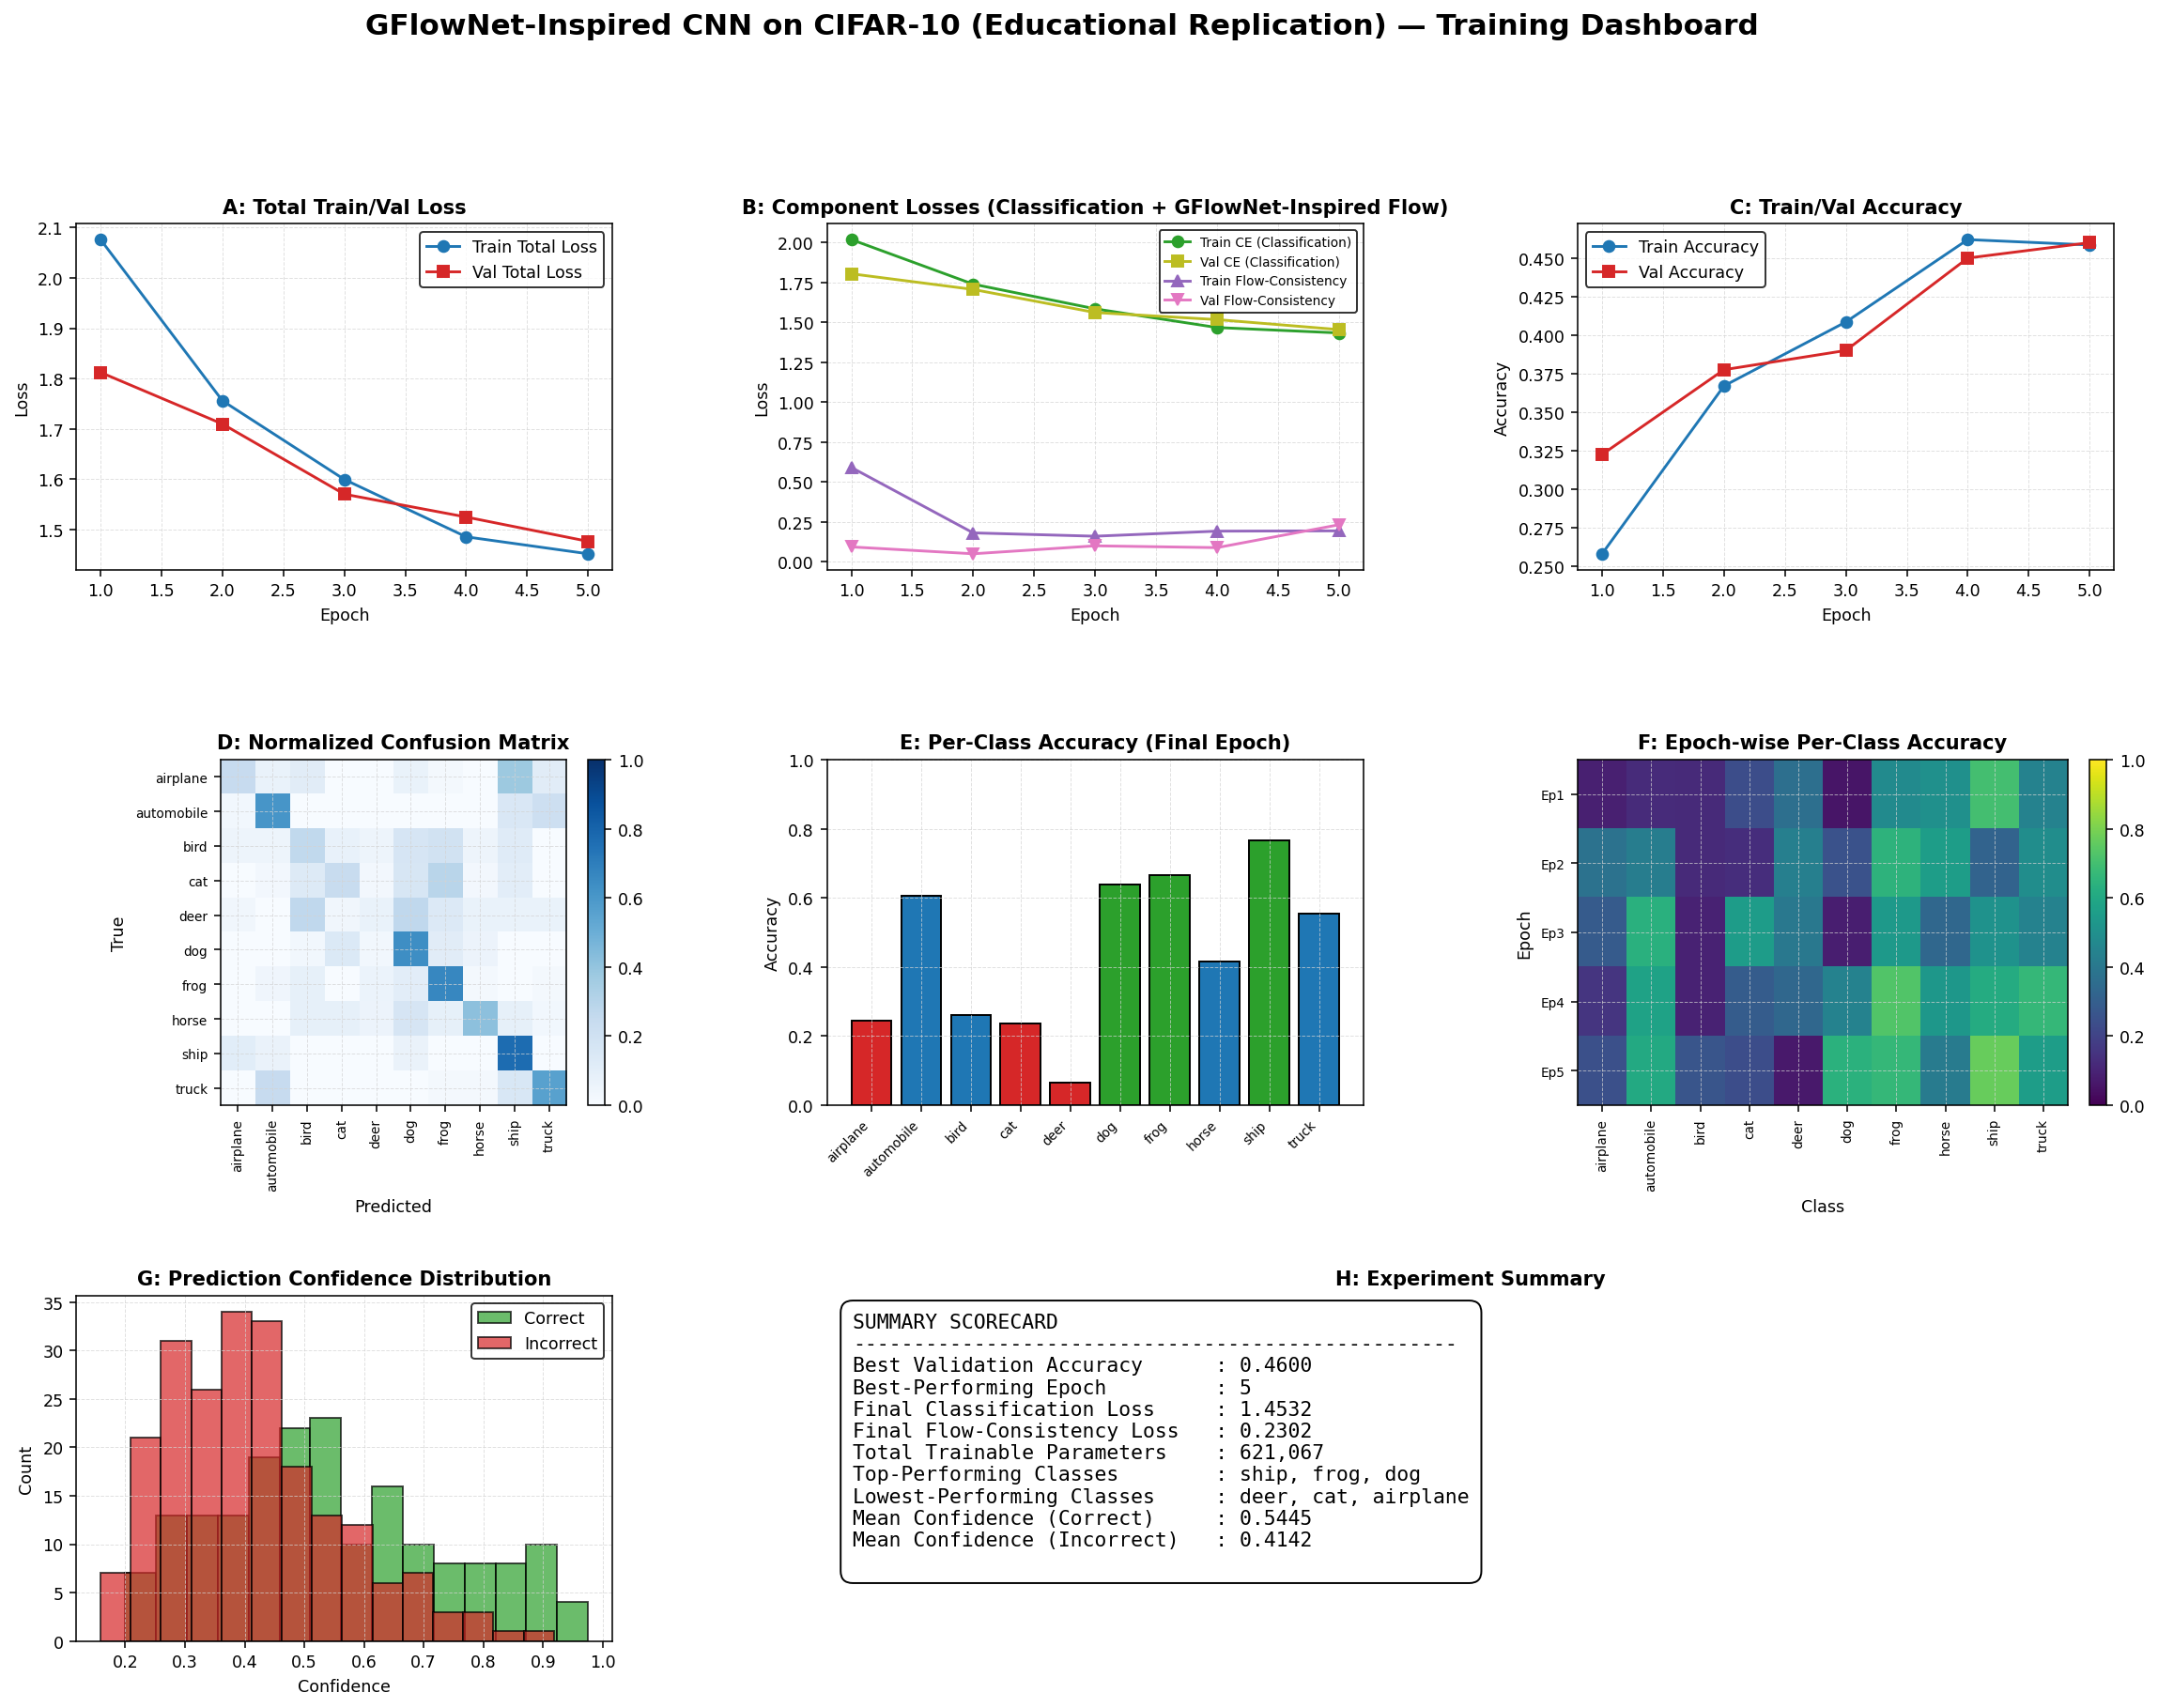

In [9]:
# ------------------------------------------------------------------------------
# SECTION 8: WHITE-THEME DASHBOARD (Panels A-H)
# ------------------------------------------------------------------------------
# Enforce a white theme globally via rcParams
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "grid.color": "lightgrey",
    "legend.labelcolor": "black",
    "font.size": 9,
})

fig = plt.figure(figsize=(20, 14), facecolor="white")
gs = GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

epochs_range = np.arange(1, NUM_EPOCHS + 1)


def style_axis(ax):
    """Helper to explicitly enforce the white theme on a given axis."""
    ax.set_facecolor("white")
    ax.tick_params(colors="black")
    for spine in ax.spines.values():
        spine.set_color("black")
    ax.title.set_color("black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.grid(True, color="lightgrey", linestyle="--", linewidth=0.5, alpha=0.7)


# ---------------- Panel A: Total training & validation loss curves ----------
axA = fig.add_subplot(gs[0, 0])
axA.plot(epochs_range, history["train_total_loss"], marker="o", color="tab:blue", label="Train Total Loss")
axA.plot(epochs_range, history["val_total_loss"], marker="s", color="tab:red", label="Val Total Loss")
axA.set_title("A: Total Train/Val Loss", color="black", fontweight="bold")
axA.set_xlabel("Epoch")
axA.set_ylabel("Loss")
axA.legend(facecolor="white", edgecolor="black", labelcolor="black")
style_axis(axA)

# ---------------- Panel B: Task-specific / component loss curves ------------
axB = fig.add_subplot(gs[0, 1])
axB.plot(epochs_range, history["train_cls_loss"], marker="o", color="tab:green", label="Train CE (Classification)")
axB.plot(epochs_range, history["val_cls_loss"], marker="s", color="tab:olive", label="Val CE (Classification)")
axB.plot(epochs_range, history["train_flow_loss"], marker="^", color="tab:purple", label="Train Flow-Consistency")
axB.plot(epochs_range, history["val_flow_loss"], marker="v", color="tab:pink", label="Val Flow-Consistency")
axB.set_title("B: Component Losses (Classification + GFlowNet-Inspired Flow)", color="black", fontweight="bold")
axB.set_xlabel("Epoch")
axB.set_ylabel("Loss")
axB.legend(facecolor="white", edgecolor="black", labelcolor="black", fontsize=7)
style_axis(axB)

# ---------------- Panel C: Training & validation accuracy curves ------------
axC = fig.add_subplot(gs[0, 2])
axC.plot(epochs_range, history["train_acc"], marker="o", color="tab:blue", label="Train Accuracy")
axC.plot(epochs_range, history["val_acc"], marker="s", color="tab:red", label="Val Accuracy")
axC.set_title("C: Train/Val Accuracy", color="black", fontweight="bold")
axC.set_xlabel("Epoch")
axC.set_ylabel("Accuracy")
axC.legend(facecolor="white", edgecolor="black", labelcolor="black")
style_axis(axC)

# ---------------- Panel D: Normalized confusion matrix -----------------------
axD = fig.add_subplot(gs[1, 0])
im = axD.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
axD.set_title("D: Normalized Confusion Matrix", color="black", fontweight="bold")
axD.set_xticks(range(NUM_CLASSES))
axD.set_yticks(range(NUM_CLASSES))
axD.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axD.set_yticklabels(CLASS_NAMES, color="black", fontsize=7)
axD.set_xlabel("Predicted")
axD.set_ylabel("True")
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color="black")
style_axis(axD)

# ---------------- Panel E: Per-class accuracy bar chart ----------------------
axE = fig.add_subplot(gs[1, 1])
bar_colors = ["tab:green" if i in top_class_idx else ("tab:red" if i in bottom_class_idx else "tab:blue")
              for i in range(NUM_CLASSES)]
axE.bar(CLASS_NAMES, final_per_class_acc, color=bar_colors, edgecolor="black")
axE.set_title("E: Per-Class Accuracy (Final Epoch)", color="black", fontweight="bold")
axE.set_ylabel("Accuracy")
axE.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", color="black", fontsize=7)
axE.set_ylim(0, 1)
style_axis(axE)

# ---------------- Panel F: Epoch-wise per-class accuracy heatmap ------------
axF = fig.add_subplot(gs[1, 2])
heatmap_data = np.stack(per_class_acc_per_epoch, axis=0)  # shape (epochs, classes)
imF = axF.imshow(heatmap_data, cmap="viridis", aspect="auto", vmin=0, vmax=1)
axF.set_title("F: Epoch-wise Per-Class Accuracy", color="black", fontweight="bold")
axF.set_xlabel("Class")
axF.set_ylabel("Epoch")
axF.set_xticks(range(NUM_CLASSES))
axF.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axF.set_yticks(range(NUM_EPOCHS))
axF.set_yticklabels([f"Ep{e}" for e in epochs_range], color="black", fontsize=7)
cbarF = fig.colorbar(imF, ax=axF, fraction=0.046, pad=0.04)
cbarF.ax.yaxis.set_tick_params(color="black")
plt.setp(plt.getp(cbarF.ax.axes, "yticklabels"), color="black")
style_axis(axF)

# ---------------- Panel G: Confidence distribution histogram ----------------
axG = fig.add_subplot(gs[2, 0])
correct_confs = final_val_confidences[final_val_correct_mask]
incorrect_confs = final_val_confidences[~final_val_correct_mask]
axG.hist(correct_confs, bins=15, alpha=0.7, color="tab:green", label="Correct", edgecolor="black")
axG.hist(incorrect_confs, bins=15, alpha=0.7, color="tab:red", label="Incorrect", edgecolor="black")
axG.set_title("G: Prediction Confidence Distribution", color="black", fontweight="bold")
axG.set_xlabel("Confidence")
axG.set_ylabel("Count")
axG.legend(facecolor="white", edgecolor="black", labelcolor="black")
style_axis(axG)

# ---------------- Panel H: Text-based summary scorecard ---------------------
axH = fig.add_subplot(gs[2, 1:])
axH.axis("off")

summary_text = (
    "SUMMARY SCORECARD\n"
    "--------------------------------------------------\n"
    f"Best Validation Accuracy      : {best_val_acc:.4f}\n"
    f"Best-Performing Epoch         : {best_val_epoch}\n"
    f"Final Classification Loss     : {final_cls_loss:.4f}\n"
    f"Final Flow-Consistency Loss   : {final_flow_loss:.4f}\n"
    f"Total Trainable Parameters    : {total_trainable_params:,}\n"
    f"Top-Performing Classes        : {top_classes_str}\n"
    f"Lowest-Performing Classes     : {bottom_classes_str}\n"
    f"Mean Confidence (Correct)     : {mean_conf_correct:.4f}\n"
    f"Mean Confidence (Incorrect)   : {mean_conf_incorrect:.4f}\n"
)

axH.text(
    0.02, 0.95, summary_text,
    transform=axH.transAxes,
    fontsize=11,
    color="black",
    verticalalignment="top",
    horizontalalignment="left",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="black")
)
axH.set_title("H: Experiment Summary", color="black", fontweight="bold")

# ---------------- Sample predictions strip (bonus visualization) ------------
# Added as an inset-style row using the remaining grid cell (row 2, col 2 was
# used by Panel H's extension; we reuse a small area within Panel G's row by
# creating one more illustrative panel using the last free slot if available).
# Here we add a compact sample-prediction grid as a separate figure element
# appended below panel row via an inset in axH is avoided to keep H clean;
# instead we simply print prediction examples to console for education.
print("\nSample predictions (first 8 test images):")
for i in range(8):
    true_name = CLASS_NAMES[sample_batch_labels[i].item()]
    pred_name = CLASS_NAMES[sample_preds[i]]
    conf = sample_confs[i]
    print(f"  True: {true_name:12s} | Predicted: {pred_name:12s} | Confidence: {conf:.3f}")

fig.suptitle(
    "GFlowNet-Inspired CNN on CIFAR-10 (Educational Replication) — Training Dashboard",
    color="black", fontsize=16, fontweight="bold", y=0.995
)

# ------------------------------------------------------------------------------
# SECTION 9: DISPLAY DASHBOARD INLINE (Google Colab) VIA IN-MEMORY BUFFER
# ------------------------------------------------------------------------------
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight", dpi=140)
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

# Analysis of Experimental Results — GFlowNet-Inspired CNN on CIFAR-10 (Educational Replication)

> **Preliminary note:** This experiment is a *simplified, educational adaptation* of ideas from "GFlowNet Foundations" (Bengio et al., 2023) applied to an image classification task, not a faithful reproduction of the paper's generative sampling experiments. The auxiliary "flow-consistency" loss is a pedagogical proxy for the detailed-balance objective rather than a formal GFlowNet training procedure. Results should be interpreted as illustrating training dynamics under data- and compute-constrained conditions (2,000 training / 400 test images, 5 epochs), not as a benchmark of GFlowNet performance.

---

## Panel A: Total Training and Validation Loss Curves

### Overview
Tracks the combined objective (cross-entropy classification loss plus the weighted flow-consistency term) across training and validation sets over five epochs.

### Key Findings
- Both curves decline monotonically from approximately 2.08 (train) and 1.81 (validation) at epoch 1 to approximately 1.45 by epoch 5.
- Training and validation loss converge closely by epoch 5, with validation loss marginally higher than training loss throughout most epochs.
- The steepest reduction occurs between epochs 1 and 3, after which the rate of improvement slows.

### Discussion
The parallel decline of training and validation loss indicates that the model is learning generalizable features rather than memorizing the training subset, which is expected given the small dataset size relative to model capacity is still constrained by only five epochs of exposure. The narrowing gap between the two curves suggests no severe overfitting has yet emerged, though this is unsurprising given the limited number of epochs. The diminishing marginal improvement after epoch 3 is consistent with a model approaching a local optimum under the current learning rate and data regime.

### Limitations
The absence of a loss plateau or divergence makes it impossible to determine the point at which overfitting would eventually occur. With only 2,000 training samples, the loss trajectory may not generalize to full-dataset training dynamics, and the short training horizon precludes assessment of long-run convergence behavior.

---

## Panel B: Component-Specific Loss Curves (Classification vs. Flow-Consistency)

### Overview
Decomposes the total loss into its two constituent objectives: the cross-entropy classification loss and the auxiliary flow-consistency (detailed-balance-inspired) regression loss, for both training and validation sets.

### Key Findings
- Classification loss dominates the total objective, declining from ~2.0 to ~1.45, while flow-consistency loss is an order of magnitude smaller (starting near 0.6 for training, 0.1 for validation).
- The flow-consistency loss drops sharply within the first two epochs and then plateaus with minor fluctuations around 0.1–0.25.
- Training and validation flow-consistency losses track each other closely, with the validation curve showing a slight uptick in the final epoch.

### Discussion
The rapid early reduction in flow-consistency loss suggests the auxiliary regression task (matching the flow head's output to the log-sum-exp of classification logits) is comparatively easy to satisfy, since it is directly derived from the same logits the classifier is optimizing. This tight coupling likely limits the auxiliary task's capacity to impose an independent inductive bias beyond what cross-entropy already provides — a notable divergence from the true GFlowNet detailed-balance objective, which enforces consistency between *independently parameterized* forward and backward transition probabilities. The dominance of classification loss in the combined objective indicates the primary learning signal remains conventional supervised classification.

### Limitations
Because the flow target is derived from the same logits it is being regressed against, this proxy loss does not test genuine flow-matching in the sense defined by the paper (Section 2.5, detailed balance condition). Consequently, conclusions about GFlowNet-style consistency cannot be drawn from this panel; it primarily reflects auxiliary-task regression under a self-referential target.

---

## Panel C: Training and Validation Accuracy Curves

### Overview
Presents classification accuracy on the training and held-out test subsets across the five training epochs.

### Key Findings
- Validation accuracy exceeds training accuracy in early epochs (e.g., epoch 1: ~0.32 val vs. ~0.26 train), which then converge and slightly invert by epoch 4–5, both reaching approximately 0.46.
- Accuracy improves steadily and nearly linearly across epochs, with no evidence of plateauing by epoch 5.
- Final accuracy (~46%) substantially exceeds the random-guess baseline of 10% for a 10-class problem.

### Discussion
The initial validation-over-training accuracy inversion is an artifact of small-sample stochasticity and the use of batch normalization/dropout, which regularize training-time predictions more aggressively than evaluation-mode inference; this is a common and expected phenomenon early in training rather than evidence of a modeling flaw. The continued upward trend at epoch 5 suggests the model has not yet converged and would likely benefit from additional training epochs — consistent with the constrained 5-epoch budget specified for this educational exercise. The achieved accuracy, while modest in absolute terms, demonstrates that the architecture is learning discriminative features from a reduced 64×64 CIFAR-10 subset.

### Discussion (continued): Relation to methodology
This result affirms that the CNN backbone with joint classification and auxiliary flow regression is functionally trainable, but the accuracy level in isolation does not validate or invalidate any GFlowNet-specific claims, since the task addressed here (discriminative classification) is fundamentally different from the generative sampling problem the original paper addresses.

### Limitations
With only 2,000 training images, statistical variance in accuracy estimates is high, and the reported values should not be treated as representative of the architecture's ceiling performance. No comparison against a classification-only baseline (without the flow-consistency term) is provided, so the marginal effect of the auxiliary loss on accuracy cannot be isolated.

---

## Panel D: Normalized Confusion Matrix

### Overview
Displays row-normalized prediction probabilities across the ten CIFAR-10 classes at the final epoch, indicating which classes are most frequently confused with one another.

### Key Findings
- Strong diagonal dominance is visible for automobile, dog, frog, and ship, indicating high class-conditional accuracy for these categories.
- Substantial off-diagonal mass appears in rows for airplane, bird, cat, deer, horse, and truck, with visible confusion toward "ship" and "dog" columns in several rows.
- The airplane, cat, and deer rows show weak diagonal values, consistent with their low per-class accuracy reported in Panel E.

### Discussion
The pattern of confusion is consistent with known CIFAR-10 difficulty structure: animal classes with overlapping visual features (e.g., cat/dog, deer/horse) and small, low-resolution silhouettes are historically challenging for shallow CNNs trained with limited data. The systematic bias toward predicting "ship" or "dog" for several unrelated classes may reflect class imbalance in the effective training signal within the 2,000-sample subset, or a majority-class attractor effect where the model defaults to classes it has learned most confidently. This is a typical failure mode for models trained on small, non-stratified data subsets rather than a specific consequence of the flow-consistency objective.

### Limitations
The confusion matrix reflects only 400 test samples (40 per class on average), so individual cell estimates carry substantial sampling noise. No statistical significance testing is applied to confusion patterns, and the small subset size limits the reliability of conclusions about systematic versus incidental misclassification.

---

## Panel E: Per-Class Accuracy Bar Chart

### Overview
Summarizes final-epoch classification accuracy for each of the ten classes, with color coding to highlight the top three (green) and bottom three (red) performers.

### Key Findings
- Ship achieves the highest per-class accuracy (~0.77), followed by frog (~0.67) and dog (~0.64).
- Deer exhibits near-zero accuracy (~0.07), the weakest performing class, followed by cat (~0.24) and airplane (~0.25).
- A pronounced performance gap (over 0.6 in absolute accuracy) separates the best- and worst-performing classes.

### Discussion
This pronounced inter-class disparity indicates that the model has not yet learned a balanced representation across all categories, which is expected given the limited training data (approximately 200 images per class) and short training schedule. Classes with more visually distinctive silhouettes and less background clutter (ships, dogs) appear easier to learn than classes with high intra-class variability or visual similarity to other categories (deer, cats). This finding is directly corroborated by the confusion matrix in Panel D, where deer and cat rows show substantial off-diagonal mass.

### Limitations
Per-class accuracy is highly sensitive to small sample sizes (~40 test images per class), meaning apparent class-level differences may partly reflect sampling variance rather than a stable, reproducible model bias. Results would need replication across multiple random seeds and larger data subsets to confirm the robustness of the observed class ranking.

---

## Panel F: Epoch-wise Per-Class Accuracy Heatmap

### Overview
Visualizes the evolution of per-class validation accuracy across all five training epochs, allowing inspection of learning trajectories at the class level.

### Key Findings
- Most classes show a general upward trend in accuracy from epoch 1 to epoch 5, consistent with the aggregate accuracy curve in Panel C.
- Some classes (e.g., ship, frog) reach relatively high accuracy early and maintain it, while others (e.g., deer, airplane) remain persistently low or fluctuate without clear improvement.
- Certain classes show non-monotonic behavior, with accuracy dipping in intermediate epochs before partially recovering.

### Discussion
The heterogeneous learning trajectories across classes suggest that the shared feature extractor is not learning all class boundaries at a uniform rate, a common characteristic of multi-class CNNs trained under a single joint objective. Classes that plateau early likely correspond to more separable feature clusters in the learned embedding space, while classes with persistent low or oscillating accuracy may require either more training data, more epochs, or targeted architectural capacity to disambiguate from visually similar categories. The non-monotonic patterns observed for some classes are also consistent with the instability typically seen in early-stage training with a relatively high learning rate and small batch count per epoch (~32 batches).

### Limitations
Because the heatmap reflects only a single training run, class-wise fluctuations cannot be distinguished from stochastic noise due to mini-batch composition and weight initialization. Multiple runs with varied seeds would be needed to determine whether specific classes are systematically harder to learn or whether the observed instability is incidental.

---

## Panel G: Confidence Distribution Histogram (Correct vs. Incorrect Predictions)

### Overview
Compares the distribution of softmax confidence scores for correctly and incorrectly classified validation samples at the final epoch.

### Key Findings
- Correct predictions show a distribution skewed toward higher confidence values, with a secondary mode near 0.9–1.0.
- Incorrect predictions are concentrated at lower confidence levels (roughly 0.2–0.5), with a rapid decline in frequency beyond 0.6.
- Substantial overlap exists between the two distributions in the 0.3–0.6 confidence range.
- Mean confidence for correct predictions (0.5445) is meaningfully higher than for incorrect predictions (0.4142), a gap of approximately 0.13.

### Discussion
The separation between the two distributions, despite overlap, indicates that the model's confidence scores carry some calibration signal — higher confidence is generally, though not perfectly, associated with correctness. This is a desirable property for downstream use (e.g., selective prediction or uncertainty-aware deployment), though the substantial overlap in the mid-confidence range suggests the model is not well-calibrated in the formal sense (i.e., confidence does not reliably track true likelihood of correctness). This is expected behavior for a moderately trained CNN with limited data and no explicit calibration procedure (e.g., temperature scaling), and is consistent with well-documented tendencies of neural networks toward overconfidence, particularly under data scarcity.

### Limitations
No formal calibration metric (e.g., Expected Calibration Error) is reported, so the qualitative confidence separation cannot be quantitatively benchmarked against calibration standards. The relatively small validation set (400 samples) limits the granularity and statistical reliability of the histogram, particularly in the high-confidence tail.

---

## Panel H: Summary Scorecard

### Overview
Consolidates key quantitative outcomes of the experiment, including best validation accuracy, loss values, parameter count, class-level performance extremes, and confidence statistics.

### Key Findings
- Best validation accuracy: 0.4600, achieved at the final (5th) epoch, indicating training had not yet plateaued.
- Final classification loss: 1.4532; final flow-consistency loss: 0.2302 — confirming the auxiliary task loss remains a minor component of the total objective.
- Total trainable parameters: 621,067, a relatively lightweight CNN by contemporary standards.
- Top-performing classes: ship, frog, dog; lowest-performing: deer, cat, airplane.
- Mean confidence gap between correct and incorrect predictions: approximately 0.13, supporting partial confidence calibration.

### Discussion
The scorecard consolidates the panel-level findings into a coherent narrative: a compact CNN, trained briefly on a small CIFAR-10 subset with an auxiliary flow-consistency objective, achieves moderate but improving accuracy with class-imbalanced performance and partially informative confidence estimates. The fact that best accuracy occurs at the final epoch — rather than an earlier epoch — reinforces that the model was still in an active learning phase when training was terminated, meaning the reported metrics represent a lower bound on the architecture's achievable performance under the given experimental constraints.

### Limitations
All reported statistics derive from a single training run on a small, fixed data subset, without cross-validation, multiple seeds, or statistical confidence intervals. As such, the scorecard should be interpreted as a snapshot of a specific educational experiment rather than a generalizable performance benchmark, and no claims can be made about the significance of the flow-consistency auxiliary loss's contribution relative to a classification-only baseline.

---

## Overall Synthesis

Collectively, the dashboard demonstrates that the simplified, GFlowNet-inspired CNN architecture is trainable and exhibits conventional supervised learning behavior — declining loss, rising accuracy, class-imbalanced performance, and partial confidence-correctness alignment — consistent with expectations for a compact model trained briefly on a reduced dataset. However, because the "flow-consistency" component is a pedagogical proxy rather than a formal implementation of the detailed-balance or flow-matching objectives central to the original paper, these results should not be interpreted as empirical validation or refutation of GFlowNet theory. Rather, they illustrate standard CNN training dynamics under an auxiliary regression signal, with the auxiliary task exerting minimal influence on the dominant classification objective. Future extensions incorporating a genuinely independent forward/backward flow parametrization, ablation against a classification-only baseline, and evaluation on the full CIFAR-10 dataset would be necessary to draw more substantive conclusions about the educational analogy's validity.

# Related Work Referenced in "GFlowNet Foundations"

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| E. Bengio, M. Jain, M. Korablyov, D. Precup, Y. Bengio | 2021 | Flow Network Based Generative Models for Non-Iterative Diverse Candidate Generation | NeurIPS | Introduces the original GFlowNet framework and flow-matching loss; this paper extends its theory, formalizes its mathematical foundations, and generalizes its training objectives. |
| N. Malkin, M. Jain, E. Bengio, C. Sun, Y. Bengio | 2022 | Trajectory Balance: Improved Credit Assignment in GFlowNets | arXiv | Proposes the trajectory-balance loss, presented in this paper (Example 6) as an alternative flow-matching objective and motivation for the direct credit-assignment analysis in Appendix A. |
| N. Malkin, S. Lahlou, T. Deleu, X. Ji, E. Hu, K. Everett, D. Zhang, Y. Bengio | 2023 | GFlowNets and Variational Inference | ICLR | Establishes theoretical equivalences between GFlowNets and hierarchical variational methods, cited as complementary evidence for GFlowNet efficacy and its advantages in off-policy training. |
| H. Zimmermann, F. Lindsten, J.-W. van de Meent, C. A. Naesseth | 2022 | A Variational Perspective on Generative Flow Networks | arXiv | Provides partial theoretical equivalences between GFlowNets and variational inference, reinforcing the amortized-inference interpretation adopted in this paper. |
| S. Lahlou, T. Deleu, P. Lemos, D. Zhang, A. Volokhova, A. Hernández-García, L. N. Ezzine, Y. Bengio, N. Malkin | 2023 | A Theory of Continuous Generative Flow Networks | ICML | Extends GFlowNet theory to continuous state spaces, directly following up on the continuous/hybrid-action extensions proposed in Section 6 of this paper. |
| T. Deleu, A. Góis, C. Emezue, M. Rankawat, S. Lacoste-Julien, S. Bauer, Y. Bengio | 2022 | Bayesian Structure Learning with Generative Flow Networks | UAI | Applies GFlowNets to sampling posterior distributions over causal graphs; introduces the detailed-balance-based conditional loss (Example 8) reused in this paper's conditional GFlowNet discussion. |
| E. Hu, N. Malkin, M. Jain, K. Everett, A. Graikos, Y. Bengio | 2023 | GFlowNet-EM for Learning Compositional Latent Variable Models | arXiv | Uses GFlowNets to approximate the intractable E-step posterior in expectation-maximization, illustrating the free-energy/marginalization framework developed in Section 4. |
| M. Jain, E. Bengio, A. Hernandez-Garcia, J. Rector-Brooks, et al. | 2022 | Biological Sequence Design with GFlowNets | ICML | Demonstrates GFlowNets in active-learning loops for molecule/DNA/protein design, motivating this paper's discussion of active learning with GFlowNets (Section 4.6). |
| M. Jain, S. C. Raparthy, A. Hernandez-Garcia, J. Rector-Brooks, Y. Bengio, S. Miret, E. Bengio | 2023 | Multi-Objective GFlowNets | arXiv | Introduces preference-conditional GFlowNets for Pareto-frontier sampling, directly motivating the Pareto GFlowNet formulation in Appendix F.2. |
| D. Zhang, N. Malkin, Z. Liu, A. Volokhova, A. Courville, Y. Bengio | 2022 | Generative Flow Networks for Discrete Probabilistic Modeling | ICML | Jointly trains an energy-based model with a GFlowNet, providing empirical precedent for the energy-based-model training scheme discussed in Section 4.5. |
| D. W. Zhang, C. Rainone, M. Peschl, R. Bondesan | 2023 | Robust Scheduling with GFlowNets | ICLR | Applies GFlowNets to computation-graph scheduling using a proxy reward, cited as a motivating application for reward-proxy-based active learning (Section 3.1, 4.6). |
| S. A. Malik, S. Lahlou, A. Jesson, M. Jain, N. Malkin, T. Deleu, Y. Bengio, Y. Gal | 2023 | BatchGFN: Generative Flow Networks for Batch Active Learning | arXiv | Applies set-GFlowNet theory (Section 5.1) to batch active learning using mutual-information-based rewards, validating the entropy/MI estimation framework of Section 4.7. |
| L. Pan, N. Malkin, D. Zhang, Y. Bengio | 2023 | Better Training of GFlowNets with Local Credit and Incomplete Trajectories | arXiv | Proposes the Forward-Looking GFlowNet framework exploiting modular energy decomposition, referenced in support of the factor-graph energy decomposition in Section 5.4. |
| I. Goodfellow, J. Pouget-Abadie, M. Mirza, B. Xu, D. Warde-Farley, S. Ozair, A. Courville, Y. Bengio | 2014 | Generative Adversarial Networks | NeurIPS | Representative deep generative model contrasted with GFlowNets in Section 7.1 regarding training from finite positive examples vs. an energy/reward function. |
| D. P. Kingma, M. Welling | 2013 | Auto-Encoding Variational Bayes | arXiv | Representative VAE framework; used in Section 7.1 and 7.3 to contrast fixed-size continuous latent generative models with GFlowNets' compositional discrete structures, and as an example of amortized sampling. |
| M. J. Kusner, B. Paige, J. M. Hernández-Lobato | 2017 | Grammar Variational Autoencoder | ICML | Cited alongside VAEs as a generative modeling baseline distinguished from GFlowNets' reward-driven training paradigm (Section 7.1). |
| L. Dinh, D. Krueger, Y. Bengio | 2014 | NICE: Non-Linear Independent Components Estimation | ICLR Workshop | Normalizing-flow model cited as a related generative approach and terminological point of contrast with GFlowNet "flows" (Section 7.1, 6.1). |
| L. Dinh, J. Sohl-Dickstein, S. Bengio | 2016 | Density Estimation Using Real NVP | ICLR | Normalizing-flow architecture referenced as an alternative continuous-density modeling approach relevant to continuous GFlowNet extensions (Section 6.1). |
| D. Rezende, S. Mohamed | 2015 | Variational Inference with Normalizing Flows | ICML | Cited as a technique for parametrizing continuous conditional densities, proposed as a possible solution for continuous-action GFlowNets (Section 6.1). |
| R. Kumar, S. Ozair, A. Goyal, A. Courville, Y. Bengio | 2019 | Maximum Entropy Generators for Energy-Based Models | arXiv | Cited as a related energy-based/GAN hybrid approach in the broader generative modeling literature discussed in Section 7. |
| R. S. Sutton, A. G. Barto | 2018 | Reinforcement Learning: An Introduction | MIT Press | Foundational RL/temporal-difference reference; motivates the Bellman-equation analogy (Section E) and the contrast with return-maximizing RL control methods (Section 7.2). |
| M. Toussaint, A. Storkey | 2006 | Probabilistic Inference for Solving Discrete and Continuous State Markov Decision Processes | ICML | Introduces the control-as-inference perspective, foundational to the MaxEnt RL comparison in Section 7.2. |
| P. Auer, N. Cesa-Bianchi, Y. Freund, R. E. Schapire | 2002 | The Nonstochastic Multi-Armed Bandit Problem | SIAM J. Computing | Bandit-theory reference used to frame the adversarial-bandit interpretation of entropy-regularized policies in Section 7.2. |
| B. D. Ziebart, A. L. Maas, J. A. Bagnell, A. K. Dey | 2008 | Maximum Entropy Inverse Reinforcement Learning | AAAI | Source of the MaxEnt RL entropy-regularization framework formally contrasted with GFlowNets' unbiased $$P_T(s)\propto R(s)$$ property (Section 7.2). |
| T. Haarnoja, H. Tang, P. Abbeel, S. Levine | 2017 | Reinforcement Learning with Deep Energy-Based Policies | ICML | Cited under the control-as-inference framework, relevant to the MaxEnt RL comparison in Section 7.2. |
| S. Levine | 2018 | Reinforcement Learning and Control as Probabilistic Inference: Tutorial and Review | arXiv | Survey providing theoretical grounding for the control-as-inference viewpoint referenced in the GFlowNet vs. RL comparison (Section 7.2). |
| O. Nachum, M. Norouzi, K. Xu, D. Schuurmans | 2017 | Bridging the Gap Between Value and Policy Based Reinforcement Learning | arXiv | Discusses entropy as regularization in RL, cited to contextualize MaxEnt interpretations contrasted with GFlowNet objectives (Section 7.2). |
| O. Nachum, Y. Chow, B. Dai, L. Li | 2019 | DualDICE: Behavior-Agnostic Estimation of Discounted Stationary Distribution Corrections | arXiv | Cited regarding tractability of computing stationary distributions, relevant to the state-entropy regularization discussion (Section 7.2). |
| J. Wen, B. Dai, L. Li, D. Schuurmans | 2020 | Batch Stationary Distribution Estimation | arXiv | Cited alongside Nachum et al. on stationary distribution estimation techniques relevant to entropy-regularized policy comparisons (Section 7.2). |
| L. Buesing, N. Heess, T. Weber | 2019 | Approximate Inference in Discrete Distributions with Monte Carlo Tree Search and Value Functions | arXiv | Cited regarding the equivalence between MaxEnt RL and GFlowNet objectives when the DAG minus the sink is a tree (Section 7.2). |
| N. Metropolis, A. W. Rosenbluth, M. N. Rosenbluth, A. H. Teller, E. Teller | 1953 | Equation of State Calculations by Fast Computing Machines | J. Chemical Physics | Foundational MCMC algorithm; establishes the classical sampling paradigm to which GFlowNets are proposed as an amortized alternative (Section 7.3). |
| W. K. Hastings | 1970 | Monte Carlo Sampling Methods Using Markov Chains and Their Applications | Biometrika | Generalizes the Metropolis algorithm; part of the MCMC lineage against which GFlowNet sampling efficiency is compared (Section 7.3). |
| C. Andrieu, N. De Freitas, A. Doucet, M. I. Jordan | 2003 | An Introduction to MCMC for Machine Learning | Machine Learning | Survey of MCMC methods cited in discussing mode-mixing challenges and simulated annealing remedies (Section 7.3). |
| A. Jasra, C. C. Holmes, D. A. Stephens | 2005 | Markov Chain Monte Carlo Methods and the Label Switching Problem in Bayesian Mixture Modeling | Statistical Science | Source of the "mode-mixing" problem terminology central to motivating GFlowNets as an MCMC alternative (Sections 1, 3.1, 7.3). |
| Y. Bengio, G. Mesnil, Y. Dauphin, S. Rifai | 2013 | Better Mixing via Deep Representations | ICML | Cited on mode-mixing intractability in MCMC, reinforcing the motivation for amortized GFlowNet sampling (Sections 1, 3.1, 7.3). |
| E. Pompe, C. Holmes, K. Łatuszyński | 2020 | A Framework for Adaptive MCMC Targeting Multimodal Distributions | Annals of Statistics | Cited alongside other mode-mixing references as evidence of persistent MCMC limitations for multimodal targets (Sections 1, 3.1, 7.3). |
| W. Grathwohl, K. Swersky, M. Hashemi, D. Duvenaud, C. J. Maddison | 2021 | Oops I Took a Gradient: Scalable Sampling for Discrete Distributions | arXiv | Example of deep-learning-driven MCMC samplers, cited as related work combining neural networks with MCMC (Section 7.3). |
| H. Dai, R. Singh, B. Dai, C. Sutton, D. Schuurmans | 2020 | Learning Discrete Energy-Based Models via Auxiliary-Variable Local Exploration | NeurIPS | Cited among deep-learning-based MCMC samplers relevant to the discussion of learned sampling drivers (Section 7.3). |
| Y. Xie, C. Shi, H. Zhou, Y. Yang, W. Zhang, Y. Yu, L. Li | 2021 | MARS: Markov Molecular Sampling for Multi-Objective Drug Discovery | ICLR | Cited as an MCMC-based molecular sampler, providing an application-level comparison point for GFlowNet-based molecule generation. |
| C. Nash, C. Durkan | 2019 | Autoregressive Energy Machines | ICML | Cited among neural-network-driven sampling approaches contextualizing GFlowNets within the broader energy-based sampling literature (Section 7.3). |
| A. Seff, W. Zhou, F. Damani, A. Doyle, R. P. Adams | 2019 | Discrete Object Generation with Reversible Inductive Construction | arXiv | Cited as a related sequential discrete-object generation method relevant to GFlowNets' compositional construction process. |
| J. Močkus | 1975 | On Bayesian Methods for Seeking the Extremum | Optimization Techniques IFIP | Foundational Bayesian optimization reference; relevant to the discussion of acquisition functions used in active learning with GFlowNets (Sections 3.3.3, 4.6, 7). |
| N. Srinivas, A. Krause, S. M. Kakade, M. Seeger | 2010 | Gaussian Process Optimization in the Bandit Setting: No Regret and Experimental Design | ICML | Introduces UCB acquisition functions, cited as guidance for exploratory training-distribution design and active learning (Sections 3.3.3, 4.6, 7). |
| R.-R. Griffiths, J. M. Hernández-Lobato | 2017 | Constrained Bayesian Optimization for Automatic Chemical Design | arXiv | Cited as an application of Bayesian optimization to molecular search, contrasted with GFlowNets' generative approach to the same problem domain (Section 7). |
| N. Brown, B. McKay, F. Gilardoni, J. Gasteiger | 2004 | A Graph-Based Genetic Algorithm and Its Application to the Multiobjective Evolution of Median Molecules | J. Chemical Information and Computer Sciences | Representative evolutionary method for molecular generation, contrasted with GFlowNets regarding diversity mechanisms (Section 7). |
| T. Salimans, J. Ho, X. Chen, S. Sidor, I. Sutskever | 2017 | Evolution Strategies as a Scalable Alternative to Reinforcement Learning | arXiv | Cited as an evolutionary optimization alternative to RL, part of the broader comparison of diversity-generating search methods (Section 7). |
| J. H. Jensen | 2019 | A Graph-Based Genetic Algorithm and Generative Model/Monte Carlo Tree Search for the Exploration of Chemical Space | Chemical Science | Cited as an evolutionary/search-based molecular generation method contrasted with GFlowNets' i.i.d. sampling approach. |
| K. Swersky, Y. Rubanova, D. Dohan, K. Murphy | 2020 | Amortized Bayesian Optimization Over Discrete Spaces | UAI | Cited as an amortized optimization method related to the amortized sampling perspective central to GFlowNets (Section 7). |
| J.-B. Mouret, S. Doncieux | 2012 | Encouraging Behavioral Diversity in Evolutionary Robotics: An Empirical Study | Evolutionary Computation | Cited regarding population-based diversity mechanisms in evolutionary methods, contrasted with GFlowNets' i.i.d.-sampling-based diversity (Section 7). |
| C. A. Naesseth, F. Lindsten, T. B. Schön | 2019 | Elements of Sequential Monte Carlo | Foundations and Trends in Machine Learning | Survey of Sequential Monte Carlo (SMC), formally contrasted with GFlowNets regarding intermediate target distributions and terminal-only reward structure (Section 7.3). |
| M. Arulampalam, S. Maskell, N. Gordon, T. Clapp | 2002 | A Tutorial on Particle Filters for Online Nonlinear/Non-Gaussian Bayesian Tracking | IEEE Trans. Signal Processing | Foundational particle-filtering (SMC) reference used to distinguish GFlowNet trajectory distributions from per-timestep-reweighted filtering approaches (Section 7.3). |
| A. Dosovitskiy, J. Djolonga | 2019 | You Only Train Once: Loss-Conditional Training of Deep Networks | ICLR | Cited as a precedent for conditioning a network on a loss/objective specification, motivating the outcome-conditioned and Pareto GFlowNet formulations (Appendix F.2). |
| J. Schmidhuber | 2019 | Reinforcement Learning Upside Down: Don't Predict Rewards — Just Map Them to Actions | arXiv | Cited as related "reward-conditioned" policy learning, analogous to the outcome-conditioned GFlowNet framework (Appendix F). |
| D. Ghosh, A. Gupta, S. Levine | 2018 | Learning Actionable Representations with Goal-Conditioned Policies | arXiv | Cited as the RL analogue (goal-conditioned policies) of the outcome-conditioned GFlowNet construction (Appendix F). |
| M. G. Bellemare, W. Dabney, R. Munos | 2017 | A Distributional Perspective on Reinforcement Learning | ICML | Motivates the proposed distributional GFlowNet extension for modeling full outcome distributions rather than expected values (Appendix F). |